# Panel S6C: Summary Statistics with Hierarchical Analysis

This notebook compares mean regrowth times between WT and ΔrhlA strains using chamber-level (position) means. Each data point represents the mean regrowth time for one chamber, with bars showing the mean ± SD across all chambers.

## Data Sources:
- WT: `../../Figure1/1E_wt/figure_code/1_first_colonies_wt_merged.csv`
- ΔrhlA: `../2A_mutants/2A_rhlA/figure_code/4_first_colonies_rhlA_merged.csv`

## Output:
- `S6C_mean_regrowth_time.pdf`

In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA LOADED
WT data shape: (195, 11)
ΔrhlA data shape: (957, 11)

Using 'position' as chamber identifier

HIERARCHICAL STATISTICS: PER-CHAMBER MEANS

WT: 17 chambers (positions)
----------------------------------------------------------------------
  Position pos0: 6.86 ± 4.42 h (n=11 colonies)
  Position pos10: 10.25 ± 2.71 h (n=2 colonies)
  Position pos11: 4.85 ± 2.01 h (n=9 colonies)
  Position pos13: 13.35 ± 4.75 h (n=10 colonies)
  Position pos14: 9.87 ± 4.22 h (n=11 colonies)
  Position pos15: 8.55 ± 4.06 h (n=10 colonies)
  Position pos16: 9.64 ± 3.85 h (n=8 colonies)
  Position pos17: 8.94 ± 3.15 h (n=3 colonies)
  Position pos18: 11.38 ± 4.67 h (n=19 colonies)
  Position pos19: 11.88 ± 4.65 h (n=5 colonies)
  Position pos2: 7.32 ± 4.38 h (n=24 colonies)
  Position pos3: 8.45 ± 3.15 h (n=16 colonies)
  Position pos4: 5.79 ± 0.65 h (n=2 colonies)
  Position pos6: 6.23 ± 3.21 h (n=22 colonies)
  Position pos7: 5.43 ± 1.42 h (n=9 colonies)
  Position pos8: 6.41 ± 1.76 h (n=20 col

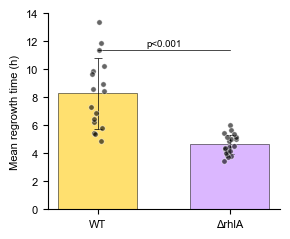


FINAL SUMMARY

Mean regrowth time (mean ± SD across chambers):
  WT:    8.27 ± 2.53 h  (n=17 chambers)
  ΔrhlA: 4.62 ± 0.71 h  (n=20 chambers)

Independent t-test: p = 0.0000
  → Statistically significant difference

ANALYSIS COMPLETE
Each dot = mean regrowth time for one chamber (position)
Total chambers: WT=17, ΔrhlA=20
Bar height = mean of chamber-level means
Error bars = SD across chambers


In [3]:
# Load data
df_wt = pd.read_csv('../../Figure1/1E_wt/figure_code/1_first_colonies_wt_merged.csv')
df_rhlA = pd.read_csv('../2A_mutants/2A_rhlA/figure_code/4_first_colonies_rhlA_merged.csv')

# Configure plotting parameters
pnas_fontsize = 8
fig_width, fig_height = 3, 2.5  # inches
replicate_markers = {'rep1': 'o', 'rep2': 'o', 'rep3': 'o'}

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Use 'position' column as chamber identifier
chamber_col = 'position'

print("=" * 70)
print("DATA LOADED")
print("=" * 70)
print(f"WT data shape: {df_wt.shape}")
print(f"ΔrhlA data shape: {df_rhlA.shape}")
print(f"\nUsing '{chamber_col}' as chamber identifier")

# Verify column exists
if chamber_col not in df_wt.columns:
    print(f"\n⚠ ERROR: '{chamber_col}' column not found!")
    print(f"Available columns: {df_wt.columns.tolist()}")
    raise ValueError(f"Column '{chamber_col}' not found in data")


def calculate_chamber_means(df, chamber_col, strain_name):
    """
    Calculate mean regrowth time for each chamber (position).
    
    Parameters
    ----------
    df : pd.DataFrame
        Colony data with 'hours' and chamber column
    chamber_col : str
        Name of the column identifying chambers
    strain_name : str
        Name of the strain for display
        
    Returns
    -------
    chamber_means : np.ndarray
        Array of per-chamber mean times
    mean_of_means : float
        Mean across all chambers
    sd_of_means : float
        Standard deviation across chambers
    sem_of_means : float
        Standard error of the mean across chambers
    """
    chambers = sorted(df[chamber_col].unique())
    chamber_means = []
    
    print(f"\n{strain_name}: {len(chambers)} chambers (positions)")
    print("-" * 70)
    
    for chamber in chambers:
        chamber_data = df[df[chamber_col] == chamber]
        mean_time = chamber_data['hours'].mean()
        std_time = chamber_data['hours'].std()
        chamber_means.append(mean_time)
        print(f"  Position {chamber}: {mean_time:.2f} ± {std_time:.2f} h "
              f"(n={len(chamber_data)} colonies)")
    
    chamber_means = np.array(chamber_means)
    
    # Overall statistics (mean and SD of chamber means)
    mean_of_means = np.mean(chamber_means)
    sd_of_means = np.std(chamber_means, ddof=1)  # Sample SD
    sem_of_means = stats.sem(chamber_means)
    
    print(f"\nAcross all {len(chambers)} chambers:")
    print(f"  Mean ± SD:  {mean_of_means:.2f} ± {sd_of_means:.2f} h")
    print(f"  Mean ± SEM: {mean_of_means:.2f} ± {sem_of_means:.2f} h")
    print(f"  Range: {chamber_means.min():.2f} - {chamber_means.max():.2f} h")
    
    return chamber_means, mean_of_means, sd_of_means, sem_of_means


# Calculate hierarchical statistics
print("\n" + "=" * 70)
print("HIERARCHICAL STATISTICS: PER-CHAMBER MEANS")
print("=" * 70)

wt_chamber_means, wt_mean, wt_sd, wt_sem = calculate_chamber_means(
    df_wt, chamber_col, 'WT'
)

rhlA_chamber_means, rhlA_mean, rhlA_sd, rhlA_sem = calculate_chamber_means(
    df_rhlA, chamber_col, 'ΔrhlA'
)

# Statistical comparison
print("\n" + "=" * 70)
print("STATISTICAL COMPARISON")
print("=" * 70)

# Check normality (Shapiro-Wilk test)
_, p_wt_norm = stats.shapiro(wt_chamber_means)
_, p_rhlA_norm = stats.shapiro(rhlA_chamber_means)

print(f"Normality tests (chamber-level means):")
print(f"  WT: p = {p_wt_norm:.4f}")
print(f"  ΔrhlA: p = {p_rhlA_norm:.4f}")

# Choose appropriate test based on normality
if p_wt_norm > 0.05 and p_rhlA_norm > 0.05:
    stat, pval = stats.ttest_ind(wt_chamber_means, rhlA_chamber_means)
    test_name = "Independent t-test"
else:
    stat, pval = stats.mannwhitneyu(
        wt_chamber_means, rhlA_chamber_means, alternative='two-sided'
    )
    test_name = "Mann-Whitney U test"

print(f"\n{test_name}: p = {pval:.4f}")

# Create figure
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Define color scheme
colors = {
    'WT': '#ffd332',
    'ΔrhlA': '#cc99ff'
}

# Bar positions
x_pos = np.arange(2)
means = [wt_mean, rhlA_mean]
sds = [wt_sd, rhlA_sd]  # Using SD, not SEM
bar_colors = [colors['WT'], colors['ΔrhlA']]

# Plot bars (mean of chamber means)
bars = ax.bar(
    x_pos, means, color=bar_colors, alpha=0.7,
    edgecolor='black', linewidth=0.5, width=0.6
)

# Add error bars (SD across chambers)
ax.errorbar(
    x_pos, means, yerr=sds,
    fmt='none', color='black', linewidth=0.5,
    capsize=3, capthick=0.5, zorder=10
)

# Overlay individual chamber data points with jitter
np.random.seed(42)  # For reproducibility
jitter_amount = 0.05

wt_x = np.zeros(len(wt_chamber_means)) + np.random.uniform(
    -jitter_amount, jitter_amount, len(wt_chamber_means)
)
rhlA_x = np.ones(len(rhlA_chamber_means)) + np.random.uniform(
    -jitter_amount, jitter_amount, len(rhlA_chamber_means)
)

ax.scatter(
    wt_x, wt_chamber_means,
    color='black', s=15, alpha=0.6, zorder=15,
    edgecolors='white', linewidths=0.5
)
ax.scatter(
    rhlA_x, rhlA_chamber_means,
    color='black', s=15, alpha=0.6, zorder=15,
    edgecolors='white', linewidths=0.5
)

# Format axes
ax.set_xticks(x_pos)
ax.set_xticklabels(['WT', 'ΔrhlA'], fontsize=pnas_fontsize)
ax.set_ylabel('Mean regrowth time (h)', fontsize=pnas_fontsize)
ax.tick_params(axis='both', labelsize=pnas_fontsize)
ax.set_ylim(bottom=0)
ax.grid(False)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add p-value if significant
if pval < 0.05:
    y_max = max([m + s for m, s in zip(means, sds)])
    ax.plot([0, 1], [y_max * 1.05, y_max * 1.05], 'k-', linewidth=0.5)
    if pval < 0.001:
        p_label = 'p<0.001'
    elif pval < 0.01:
        p_label = f'p={pval:.3f}'
    else:
        p_label = f'p={pval:.2f}'
    ax.text(0.5, y_max * 1.08, p_label, ha='center', fontsize=7)

# Save figure
plt.tight_layout()
output_path = 'S6C_mean_regrowth_time.pdf'
plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
print(f"\n✓ Saved: {output_path}")

plt.show()

# Print final summary
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"\nMean regrowth time (mean ± SD across chambers):")
print(f"  WT:    {wt_mean:.2f} ± {wt_sd:.2f} h  (n={len(wt_chamber_means)} chambers)")
print(f"  ΔrhlA: {rhlA_mean:.2f} ± {rhlA_sd:.2f} h  (n={len(rhlA_chamber_means)} chambers)")
print(f"\n{test_name}: p = {pval:.4f}")
if pval < 0.05:
    print("  → Statistically significant difference")
else:
    print("  → No significant difference")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)
print(f"Each dot = mean regrowth time for one chamber (position)")
print(f"Total chambers: WT={len(wt_chamber_means)}, ΔrhlA={len(rhlA_chamber_means)}")
print(f"Bar height = mean of chamber-level means")
print(f"Error bars = SD across chambers")
print("=" * 70)